# Week 2.1 — Finite Differences: Order of Accuracy and the Error Floor

Everything in this notebook is ready to run: **run the cells top to bottom and
check what comes out against the "What you should see" notes.** Anything labelled *Optional* is
there if you want to push further; it is not required.

Three things, in order:

1. the three-point stencil really is $\mathcal{O}(h^2)$ — Problem 1;
2. what happens when you keep shrinking $h$ - see also the concept check in the slides;
3. the 1D boundary value problem assembled and solved — Problem 2, plus the convergence rate for a
   right-hand side that is not a polynomial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

## Part 1: the three-point stencil is second order

For $u(x)=\sin(\pi x)$ we know the answer exactly: $u''(0.5)=-\pi^2$. In the approximation

$$D_{xx}^h u(x)=\frac{u(x+h)-2u(x)+u(x-h)}{h^2}=u''(x)+\frac{h^2}{12}u^{(4)}(\xi)$$

the error will be divided by $4$ every time $h$ is halved, because $(h/2)^2 = h^2/4$.

In [2]:
u = lambda x: np.sin(np.pi * x)
x0 = 0.5
exact = -np.pi**2                      # u''(0.5) for u = sin(pi x)

D_xx = lambda h: (u(x0 + h) - 2 * u(x0) + u(x0 - h)) / h**2

print(f"exact u''(0.5) = {exact:.8f}\n")
print(f"{'h':>8} {'D_xx^h u(0.5)':>16} {'error':>12} {'ratio':>8}")
prev = None
for h in [0.25, 0.125, 0.0625]:
    approx = D_xx(h)
    err = abs(approx - exact)
    ratio = "---" if prev is None else f"{prev / err:.3f}"
    print(f"{h:>8} {approx:>16.8f} {err:>12.4e} {ratio:>8}")
    prev = err

# The leading term of the error, h^2/12 * u''''(xi), predicts the h = 0.25 entry:
predicted = 0.25**2 / 12 * np.pi**4     # u'''' (0.5) = pi^4
print(f"\npredicted error at h = 0.25: {predicted:.4f}   observed: {abs(D_xx(0.25) - exact):.4f}")

exact u''(0.5) = -9.86960440

       h    D_xx^h u(0.5)        error    ratio
    0.25      -9.37258300   4.9702e-01      ---
   0.125      -9.74341984   1.2618e-01    3.939
  0.0625      -9.83793643   3.1668e-02    3.985

predicted error at h = 0.25: 0.5073   observed: 0.4970


## Part 2: the error floor — where "smaller $h$" stops working

Part 1 suggests an easy test: keep halving $h$ and keep gaining accuracy. So take
$h$ all the way down to $10^{-8}$ and see.

There are *two* errors in that quotient, not on (from which the second is not visible in exact arithmetic). The truncation error
$\frac{h^2}{12}\lVert u^{(4)}\rVert_\infty$ decreases as $h$ shrinks. But $u(x+h)-2u(x)+u(x-h)$ is a
difference of numbers that are nearly equal, so it loses digits due to cancellation, and then we
divide by $h^2$, which is tiny. That rounding contribution is about
$\frac{4\varepsilon_{\mathrm{mach}}\lVert u\rVert_\infty}{h^2}$ and it *grows* as $h$ shrinks.

In [3]:
eps = np.finfo(float).eps
hs = np.logspace(-1, -9, 200)
err = np.array([abs(D_xx(h) - exact) for h in hs])

trunc = hs**2 / 12 * np.pi**4           # ||u''''||_inf = pi^4
round_ = 4 * eps / hs**2                # ||u||_inf = 1

i = err.argmin()
print(f"measured minimum error {err[i]:.3e} at h = {hs[i]:.3e}")
print(f"eps_mach^(1/4)        = {eps**0.25:.3e}")
print(f"\nerror at h = 1e-2: {abs(D_xx(1e-2) - exact):.2e}")
print(f"error at h = 1e-6: {abs(D_xx(1e-6) - exact):.2e}")
print(f"error at h = 1e-8: {abs(D_xx(1e-8) - exact):.2e}   <- no correct digits left")

measured minimum error 7.074e-09 at h = 5.053e-05
eps_mach^(1/4)        = 1.221e-04

error at h = 1e-2: 8.12e-04
error at h = 1e-6: 5.48e-05
error at h = 1e-8: 9.88e-01   <- no correct digits left


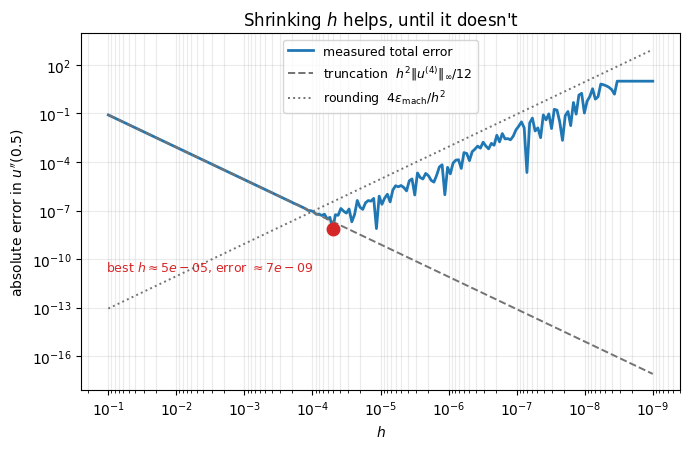

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.6))

ax.loglog(hs, err, lw=2, label="measured total error")
ax.loglog(hs, trunc, "--", color="0.45", lw=1.4, label=r"truncation  $h^2\|u^{(4)}\|_\infty/12$")
ax.loglog(hs, round_, ":", color="0.45", lw=1.4, label=r"rounding  $4\varepsilon_{\rm mach}/h^2$")

ax.plot(hs[i], err[i], "o", ms=9, color="C3", zorder=5)
ax.annotate(f"best $h\\approx{hs[i]:.0e}$, error $\\approx{err[i]:.0e}$",
            xy=(hs[i], err[i]), xytext=(-14, -30), textcoords="offset points",
            ha="right", fontsize=9, color="C3")

ax.set_xlabel("$h$")
ax.set_ylabel("absolute error in $u''(0.5)$")
ax.set_title("Shrinking $h$ helps, until it doesn't")
ax.invert_xaxis()                        # h decreasing to the right, as in the story
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

**What you should see.** A V shaped graph: with $h$ decreasing to the right, the error falls along the
truncation branch, bottoms out at roughly $10^{-8}$ somewhere near $h\approx5\cdot10^{-5}$, and then
climbs the rounding branch. At $h=10^{-8}$ the answer has **no correct digits at all** — the error
is about $1$, and the true value is about $-9.87$.

Three things worth noticing.

- The floor is not a bug in the code or in NumPy. It is $\varepsilon_{\mathrm{mach}}$ arriving
  through a division by $h^2$.
- The bottom of the V is *ragged*, and the exact location of the minimum moves if you change the
  number of sample points. Rounding error is not a smooth function of $h$. Only the two straight branches are reproducible.
- The estimate predicts the order not the constant. Balancing the two terms with the
  constants kept gives
  $h^\star=\bigl(48\varepsilon_{\mathrm{mach}}\lVert u\rVert_\infty/\lVert u^{(4)}\rVert_\infty\bigr)^{1/4}
  \approx10^{-4}$, against a measured argmin near $5\cdot10^{-5}$; the rounding term
  $4\varepsilon_{\mathrm{mach}}/h^2$ is an upper bound, so the real curve turns a little later and a
  little lower. What is robust is the *scaling* $h^\star\sim\varepsilon_{\mathrm{mach}}^{1/4}$.

In [ ]:
# The balance point with the constants kept, against the measured minimum. Same order,
# different constant: the 4*eps/h^2 term is a bound, not the error actually committed.
h_star = (48 * eps * 1.0 / np.pi**4)**0.25
print(f"balanced h* = {h_star:.3e}    measured argmin = {hs[i]:.3e}    eps^(1/4) = {eps**0.25:.3e}")

## Part 3: the 1D boundary value problem

Now the matrix. For $-u''=f$ on $(0,1)$ with $u(0)=\alpha$, $u(1)=\beta$, interior points
$x_i=ih$, $h=1/(n+1)$:

$$A=\frac{1}{h^2}\mathrm{tridiag}(-1,2,-1)\in\mathbb{R}^{n\times n},\qquad
g_i=f(x_i),\quad g_1 \leftarrow g_1+\frac{\alpha}{h^2},\quad g_n \leftarrow g_n+\frac{\beta}{h^2}.$$

In [5]:
def poisson_1d(n):
    # A = tridiag(-1,2,-1)/h^2 (sparse, CSR), together with the grid spacing h.
    h = 1 / (n + 1)
    A = sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(n, n), format="csr") / h**2
    return A, h


def solve_bvp(n, f, alpha=0.0, beta=0.0):
    # Solve -u'' = f on (0,1) with Dirichlet data; return interior grid and solution.
    A, h = poisson_1d(n)
    x = np.linspace(0, 1, n + 2)[1:-1]
    g = f(x).astype(float)
    g[0] += alpha / h**2
    g[-1] += beta / h**2
    return x, spla.spsolve(A.tocsc(), g)


# Problem 2: f = 1, n = 4, homogeneous Dirichlet. Exact solution u(x) = x(1-x)/2.
x, uh = solve_bvp(4, lambda x: np.ones_like(x))
print("computed :", np.array2string(uh, precision=6))
print("exact    :", np.array2string(x * (1 - x) / 2, precision=6))
print("max error:", f"{np.max(np.abs(uh - x * (1 - x) / 2)):.2e}")

computed : [0.08 0.12 0.12 0.08]
exact    : [0.08 0.12 0.12 0.08]
max error: 2.78e-17


**What you should see.** $u=(0.08,\,0.12,\,0.12,\,0.08)$ and an error at the level of round-off —
not small, **zero**. The discrete solution is *exact* here, because the true solution is a quadratic
and the truncation error carries $u^{(4)}$, which vanishes identically for a quadratic. That is a special case, so try a right-hand side whose solution is not a polynomial.

In [6]:
# u(x) = sin(pi x)  =>  -u'' = pi^2 sin(pi x). Now u'''' is not zero and we should see O(h^2).
f = lambda x: np.pi**2 * np.sin(np.pi * x)
u_exact = lambda x: np.sin(np.pi * x)

print(f"{'n':>6} {'h':>10} {'max error':>12} {'ratio':>8}")
prev = None
for n in [9, 19, 39, 79, 159]:
    x, uh = solve_bvp(n, f)
    e = np.max(np.abs(uh - u_exact(x)))
    ratio = "---" if prev is None else f"{prev / e:.3f}"
    print(f"{n:>6} {1/(n+1):>10.5f} {e:>12.4e} {ratio:>8}")
    prev = e

     n          h    max error    ratio
     9    0.10000   8.2654e-03      ---
    19    0.05000   2.0587e-03    4.015
    39    0.02500   5.1420e-04    4.004
    79    0.01250   1.2852e-04    4.001
   159    0.00625   3.2128e-05    4.000


**What you should see.** The error ratio settles at $4$ again: halving $h$ quarters the error, so
the *solution* of the linear system inherits the second order of the stencil that built it. Notice also that nothing here went near the error floor of Part 2. Solving the BVP uses $h$ of order $10^{-2}$, nowhere near $10^{-5}$.

## Optional

Not required — for anyone who wants to keep going.

- Repeat Part 2 in single precision (`np.float32`). Predict where the minimum moves before you run
  it: $\varepsilon_{\mathrm{mach}}$ is about $1.2\cdot10^{-7}$ there.
- Re-run Part 2 with the *first* derivative, central and forward. The forward difference balances
  at $h\sim\varepsilon_{\mathrm{mach}}^{1/2}$ rather than $\varepsilon_{\mathrm{mach}}^{1/4}$ —
  a shallower division by $h$ means a different floor.
- Add a reaction term: solve $-u''+cu=f$ by changing one line of `poisson_1d`, and watch the
  condition number of $A$ improve as $c$ grows (Problems 3 and 4).